# Example 9A: Cubic Splines

A **cubic spline** is a modeling method that is composed of multiple segments of cubic polynomials, each defining the curve between two points. The key characteristic of cubic splines is their smoothness, not only in the curve itself but also in the first and second derivatives at each knot--the location where cubic segments meet.

### Constructing a Cubic Spline

To construct a cubic spline from a dataset, the following steps are typically involved:

1. **Divide the Data**: The range of the dataset is segmented based on knot locations.

2. **Cubic Polynomials**: In each interval, a separate cubic polynomial is established. This polynomial is responsible for modeling the curve within its specific interval.

The outcome is a smoothly flowing curve that closely follows the data points' trend. Cubic splines are extensively employed in fields like computer graphics, data fitting, and numerical analysis due to their optimal balance between smoothness and accuracy.


In [51]:
# Standard imports
import numpy as np
import matplotlib.pyplot as plt

# For model and evaluation
from scipy.interpolate import splrep, splev
from sklearn.model_selection import train_test_split

Here, we model data that follows a sign curve: $$Y = \sin(X).$$

In [52]:
# Generate some sample data points
np.random.seed(9)
x = np.linspace(0, 10, 100)
y = np.sin(x) + np.random.normal(0, 0.1, 100)  # Generate noisy data

y_true = np.sin(x)

# Split the data into training, validation, and testing sets
X_train, X_temp, y_train, y_temp = train_test_split(x, y, test_size=0.4, random_state=9)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=9)

# For fitting the function once hyperparameters are selected
X_train_val = np.concatenate((X_train, X_val))
y_train_val = np.concatenate((y_train, y_val))

# Sort to ensure strictly increasing x values
sorted_indices = np.argsort(X_train)
X_train = X_train[sorted_indices]
y_train = y_train[sorted_indices]

sorted_indices = np.argsort(X_val)
X_val = X_val[sorted_indices]
y_val = y_val[sorted_indices]

sorted_indices = np.argsort(X_train_val)
X_train_val = X_train_val[sorted_indices]
y_train_val = y_train_val[sorted_indices]

In this setup, we stick with only one knot and attempt to locate the ideal using our standard search method for hyperparameters. 

In [45]:
# Define search space for knots
knots = np.arange(0.25, 9, 0.25)
mse_values = []

# Perform cubic spline interpolation for each potential knot location
for knot_location in knots:
    # Fit the cubic spline using all data points and current knots
    tck = splrep(X_train, y_train, t=[knot_location])
    
    # Calculate the Mean Squared Error (MSE) on the validation set
    mse = np.mean((splev(X_val, tck) - y_val) ** 2)
    mse_values.append(mse)

# Find the knot location that results in the lowest MSE on the validation set
best_mse = min(mse_values)
best_knot = knots[mse_values.index(best_mse)]

print(f"The best knot location is {best_knot}")

The best knot location is 4.25


To better understand these models we've looked through, we plot the MSE values against the potential knot locations. 

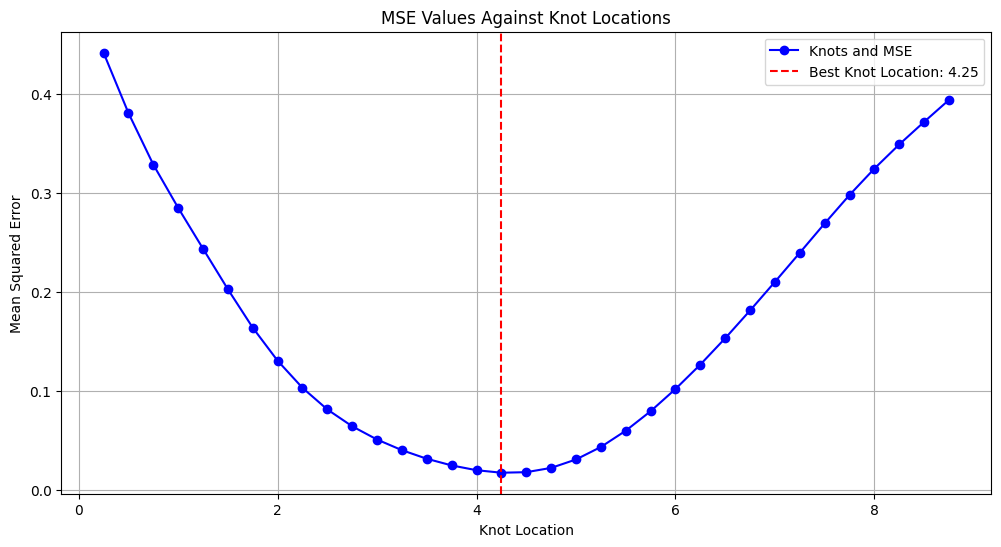

In [50]:
# Plot knot location and mse
plt.figure(figsize=(12, 6))
plt.plot(knots, mse_values, marker='o', label='Knots and MSE', color='blue')
plt.axvline(x=best_knot, linestyle='--', color='red', label=f'Best Knot Location: {best_knot:.2f}')
plt.xlabel('Knot Location')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.title('MSE Values Against Knot Locations')
plt.grid(True)
plt.show()

Based on our ideal knot, we construct our model and evaluate it against the testing set. 

In [47]:
# Fit the final cubic spline using the best knot location on the combined training and validation sets
final_tck = splrep(X_train_val, y_train_val, t=[best_knot])

# Evaluate the final spline on the testing set
mse_test = np.mean((splev(X_test, final_tck) - y_test) ** 2)
r_squared_test = 1 - (np.sum((splev(X_test, final_tck) - y_test) ** 2) / np.sum((y_test - np.mean(y_test)) ** 2))

print(f"Mean Squared Error (MSE) on Testing Set: {mse_test:.4f}")
print(f"R-squared on Testing Set: {r_squared_test:.4f}")

Mean Squared Error (MSE) on Testing Set: 0.0229
R-squared on Testing Set: 0.9462


Because we are using syntethetic data, we can compare our constructed cubic spline against the ground truth to see how well we did. 

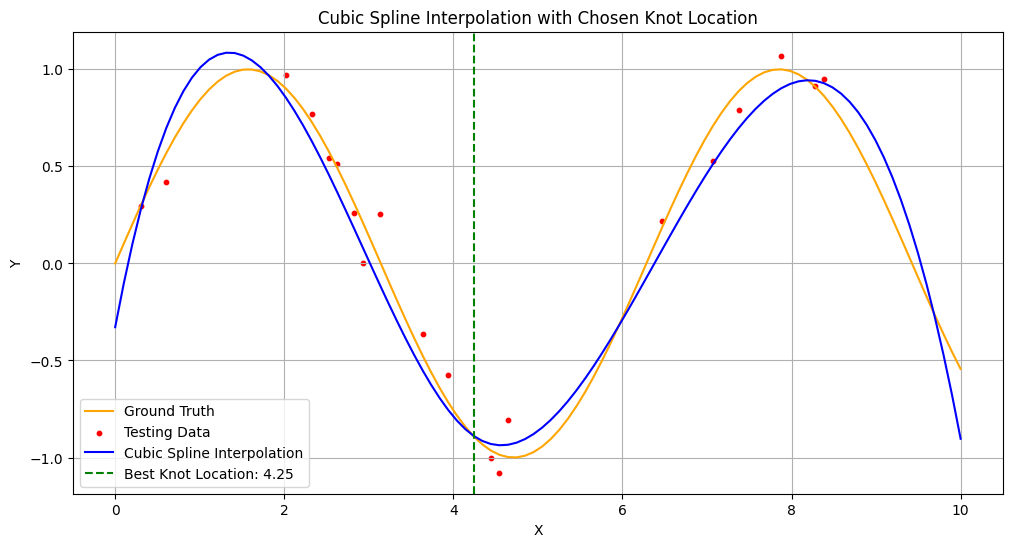

In [53]:
# Generate points for the final interpolated curve
x_interp_final = np.linspace(x.min(), x.max(), 100)
y_interp_final = splev(x_interp_final, final_tck)

# Plot the training data, the best-fitting cubic spline, and the chosen knot location
plt.figure(figsize=(12, 6))
plt.plot(x, y_true, label='Ground Truth', color='orange')
plt.scatter(X_test, y_test, label='Testing Data', color='red', s=10)
plt.plot(x_interp_final, y_interp_final, label='Cubic Spline Interpolation', color='blue')
plt.axvline(x=best_knot, linestyle='--', color='green', label=f'Best Knot Location: {best_knot:.2f}')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.title('Cubic Spline Interpolation with Chosen Knot Location')
plt.grid(True)
plt.show()


## A Two Knot Example

Because the previous example only considered one knot, let's look at a case where we restrict to two knots. 

In [90]:
# Constructing the knots array
knots = []
step = 0.2

for i in np.arange(0+step, 10-step, step):
    for j in np.arange(i + step, 10-step, step):
        knots.append([i, j])

knots = np.array(knots)

mse_values = []

# Perform cubic spline interpolation for each combination of knot locations
for knot_pair in knots:
    # Fit the cubic spline using all data points and current knots
    tck = splrep(X_train, y_train, t=knot_pair)

    # Calculate the Mean Squared Error (MSE) on the validation set
    mse = np.mean((splev(X_val, tck) - y_val) ** 2)
    mse_values.append(mse)

# Find the knot locations that result in the lowest MSE on the validation set
best_knot1, best_knot2 = tuple(knots[np.argmin(mse_values)])
print(f"The best knot locations are {best_knot1} and {best_knot2}")

The best knot locations are 4.800000000000001 and 8.600000000000005


Let's try to visualize the locations of the two knots with the MSE values. 

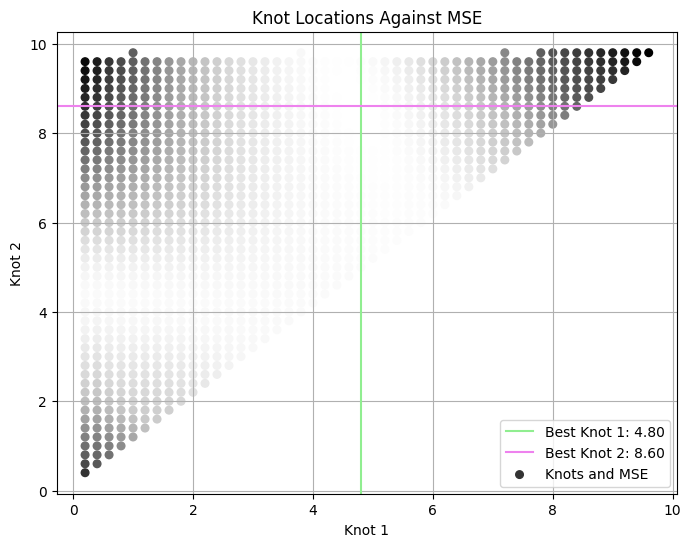

In [107]:
# Plot the training data, the best-fitting cubic spline, and the chosen knot locations
plt.figure(figsize=(8, 6))
plt.axvline(x=best_knot1, color='lightgreen', label=f'Best Knot 1: {best_knot1:.2f}')
plt.axhline(y=best_knot2, color='violet', label=f'Best Knot 2: {best_knot2:.2f}')
plt.scatter(knots[:,0], knots[:,1], c=mse_values, label='Knots and MSE', cmap='binary', s=30)
plt.xlabel('Knot 1')
plt.ylabel('Knot 2')
plt.legend()
plt.title('Knot Locations Against MSE')
plt.grid(True)
plt.show()

Based on our selected knot locations, we can construct our final model and compute its metrics. 

In [110]:
# Fit the final cubic spline using the best knot locations on the combined training and validation sets
final_tck = splrep(X_train_val, y_train_val, t=[best_knot1, best_knot2])

# Evaluate the final spline on the testing set
mse_test = np.mean((splev(X_test, final_tck) - y_test) ** 2)
r_squared_test = 1 - (np.sum((splev(X_test, final_tck) - y_test) ** 2) / np.sum((y_test - np.mean(y_test)) ** 2))

print(f"Mean Squared Error (MSE) on Testing Set: {mse_test:.4f}")
print(f"R-squared on Testing Set: {r_squared_test:.4f}")

Mean Squared Error (MSE) on Testing Set: 0.0165
R-squared on Testing Set: 0.9612


Finally, we can plot the cubic spline with the knot locations marked. 

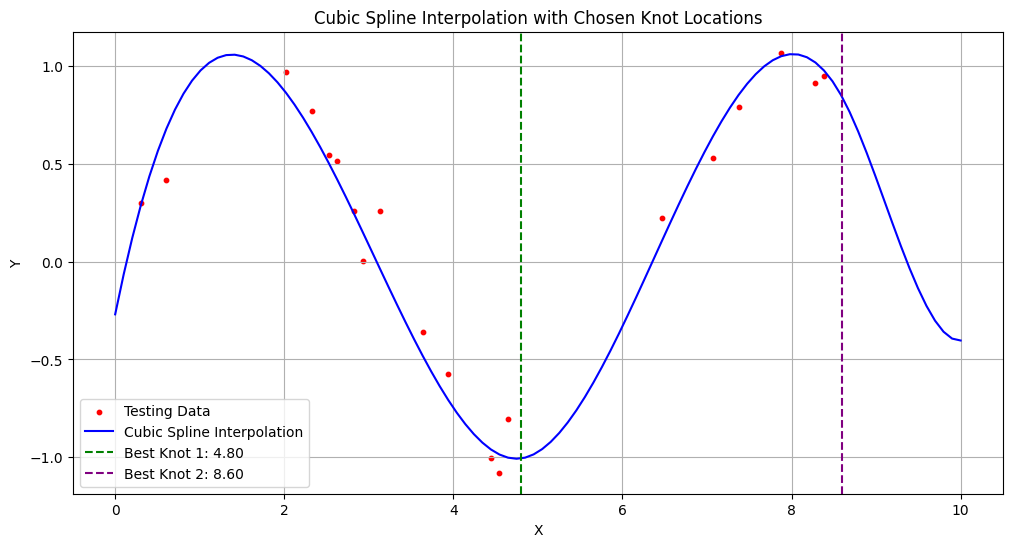

In [111]:
# Generate points for the final interpolated curve
x_interp_final = np.linspace(x.min(), x.max(), 100)
y_interp_final = splev(x_interp_final, final_tck)

# Plot the training data, the best-fitting cubic spline, and the chosen knot locations
plt.figure(figsize=(12, 6))
plt.scatter(X_test, y_test, label='Testing Data', color='red', s=10)
plt.plot(x_interp_final, y_interp_final, label='Cubic Spline Interpolation', color='blue')
plt.axvline(x=best_knot1, linestyle='--', color='green', label=f'Best Knot 1: {best_knot1:.2f}')
plt.axvline(x=best_knot2, linestyle='--', color='purple', label=f'Best Knot 2: {best_knot2:.2f}')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.title('Cubic Spline Interpolation with Chosen Knot Locations')
plt.grid(True)
plt.show()